This is basically for checking if the customer features csv loaded correctly

In [5]:
import pandas as pd
from pathlib import Path
project_path = Path.cwd().parent
extracted_features_path = project_path/"data"/"processed"/"customer_features.csv"
print(project_path)

c:\Users\HP\Desktop\customer-segmentation


array([[<Axes: title={'center': 'Customer ID'}>,
        <Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>,
        <Axes: title={'center': 'TotalQuantity'}>,
        <Axes: title={'center': 'UniqueProducts'}>],
       [<Axes: title={'center': 'AverageOrderValue'}>, <Axes: >,
        <Axes: >]], dtype=object)

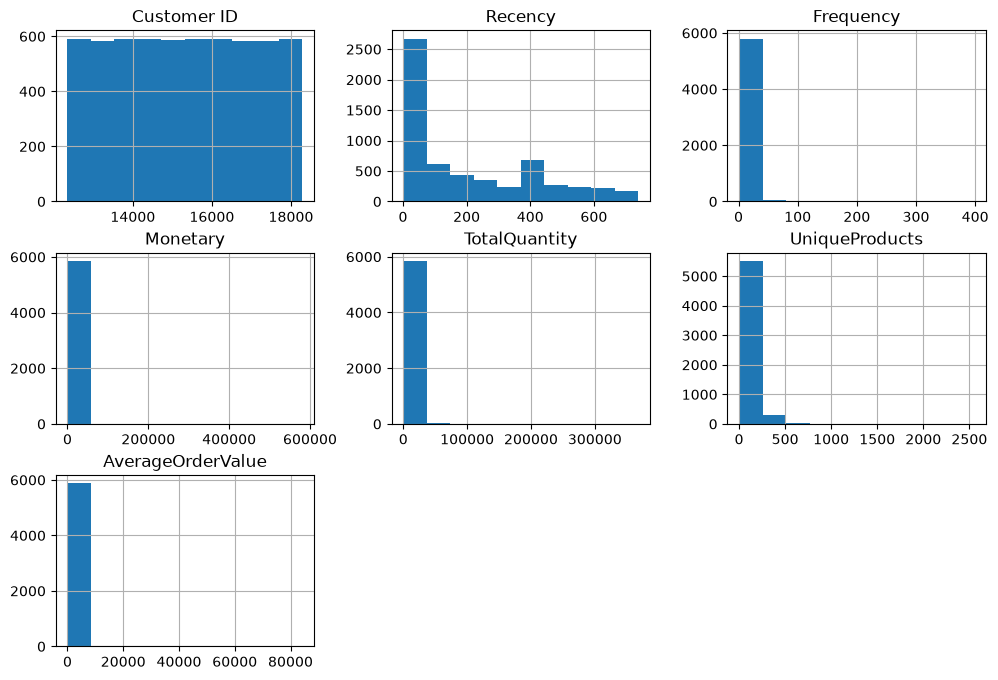

In [ ]:
# we are looking at the extracted features and viewing them in histogram to see how data is skewed. For most of the features data is very right skewed.
df = pd.read_csv(extracted_features_path)
df.head()
df.hist(figsize=(12,8))

array([[<Axes: title={'center': 'Customer ID'}>,
        <Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>,
        <Axes: title={'center': 'TotalQuantity'}>,
        <Axes: title={'center': 'UniqueProducts'}>],
       [<Axes: title={'center': 'AverageOrderValue'}>, <Axes: >,
        <Axes: >]], dtype=object)

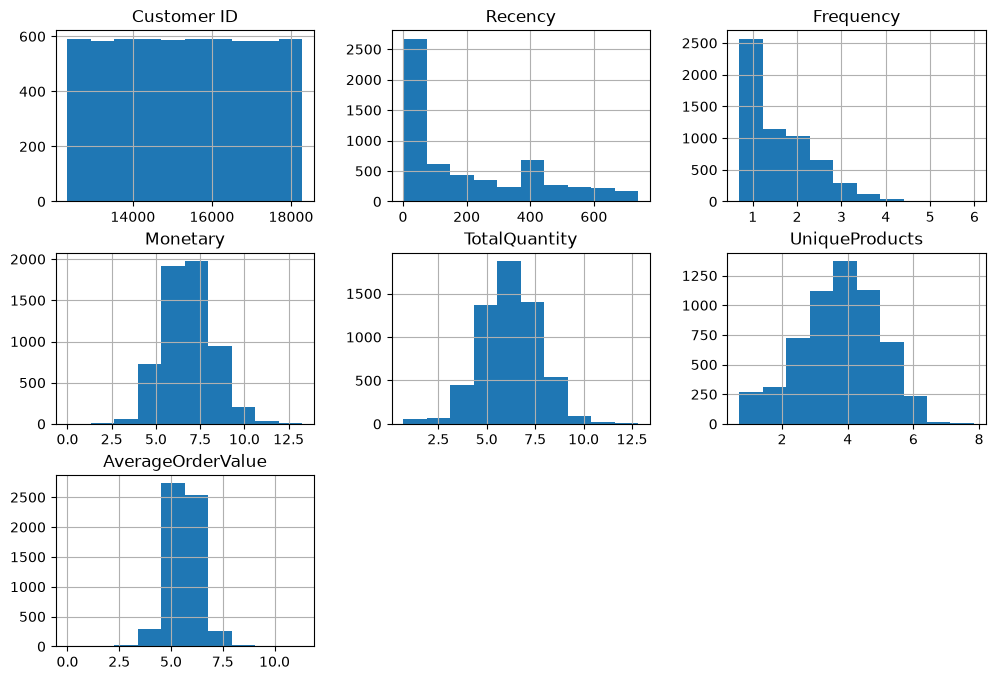

In [ ]:
import numpy as np

# Since the data is right skewed we are doing a log transformation to make it more balanced
log_features = ["Frequency", "Monetary", "TotalQuantity", "UniqueProducts", "AverageOrderValue"]

df[log_features] = np.log1p(df[log_features])
df.hist(figsize=(12,8))

array([[<Axes: title={'center': 'Customer ID'}>,
        <Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>,
        <Axes: title={'center': 'TotalQuantity'}>,
        <Axes: title={'center': 'UniqueProducts'}>],
       [<Axes: title={'center': 'AverageOrderValue'}>, <Axes: >,
        <Axes: >]], dtype=object)

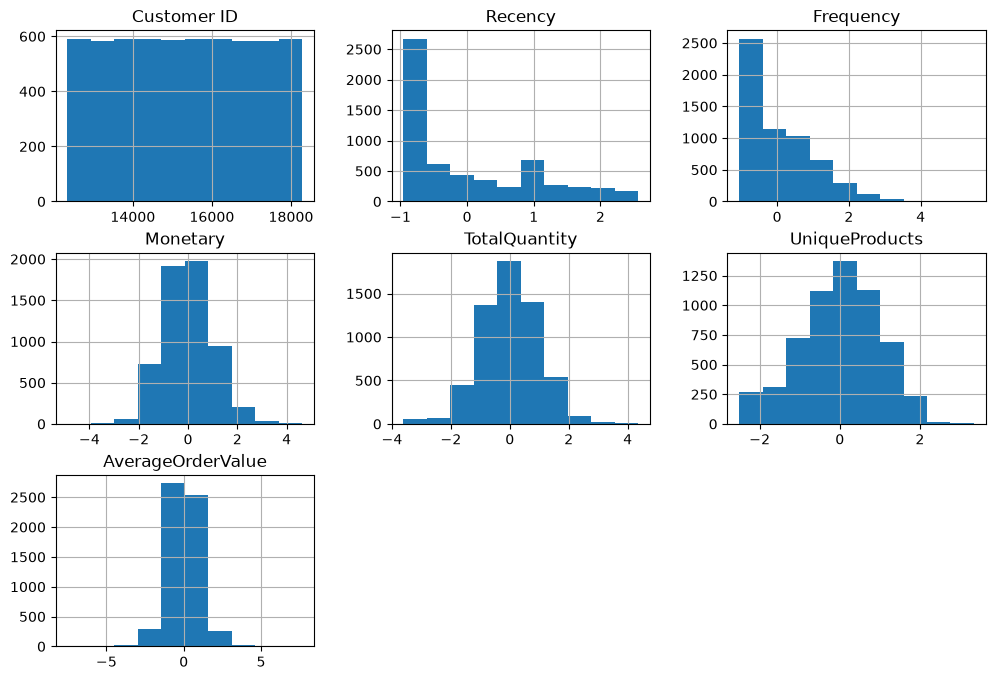

In [21]:
# now we are normalizing the data
from sklearn.preprocessing import StandardScaler

features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AverageOrderValue"
]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
df.hist(figsize=(12,8))